# Analytical Validation of pyCAFE
## Acoustic Eigenfrequencies of a 2D Rectangular Rigid Cavity

---

This notebook validates the finite element implementation in **pyCAFE** by comparing computed acoustic eigenfrequencies against the exact analytical solution for a two-dimensional rectangular cavity with rigid walls.

The test problem is a classical benchmark in computational acoustics and is widely used to assess the accuracy and convergence properties of acoustic FEM codes [1–4].

### Problem statement

Consider a 2D rectangular domain $\Omega = [0, L_x] \times [0, L_y]$ filled with an ideal compressible fluid. The governing equation is the **Helmholtz equation** in the frequency domain:

$$\nabla^2 p + k^2 p = 0 \quad \text{in } \Omega$$

with $k = \omega / c_0$ the acoustic wavenumber, $\omega = 2\pi f$ the angular frequency, and $c_0$ the speed of sound.

On all four walls the **rigid (hard) wall** condition is imposed:

$$\frac{\partial p}{\partial n} = 0 \quad \text{on } \partial \Omega$$

This is a homogeneous Neumann condition and represents the natural boundary condition in the weak FEM formulation — no matrix modification is required.

### Exact analytical solution

The exact eigenfrequencies of the rigid rectangular cavity are [1, 2]:

$$f_{mn} = \frac{c_0}{2} \sqrt{\left(\frac{m}{L_x}\right)^2 + \left(\frac{n}{L_y}\right)^2}, \quad m, n = 0, 1, 2, \ldots, \quad (m,n) \neq (0,0)$$

where $m$ and $n$ are the number of half-pressure cycles along $x$ and $y$ respectively.

The corresponding mode shapes (eigenfunctions) are:

$$\Phi_{mn}(x,y) = \cos\left(\frac{m\pi x}{L_x}\right) \cos\left(\frac{n\pi y}{L_y}\right)$$

### FEM discretisation

The FEM model uses **CQUAD8 serendipity elements** (8-node, second-order quadrilateral). The discrete generalized eigenvalue problem is:

$$\mathbf{K}\,\boldsymbol{\varphi} = \lambda\, \mathbf{M}\,\boldsymbol{\varphi}, \quad \lambda = \omega^2$$

where $\mathbf{K}$ is the acoustic stiffness matrix and $\mathbf{M}$ is the acoustic mass matrix [3, 4].

---
## 1 — Imports

In [1]:
import gmsh
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pathlib

import pycafe
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced
from pycafe.build_matrices.assembly_cquad8 import expand_mode_to_full

print("All imports successful.")

All imports successful.


---
## 2 — Physical parameters

The cavity is filled with **air at 20 °C**. Dimensions are chosen to yield well-separated eigenfrequencies in the low-to-mid frequency range.

In [2]:
# ── Fluid (air at 20 °C) ───────────────────────────────────────────────────
c0  = 343.0   # speed of sound  [m/s]
rho = 1.204   # density          [kg/m³]

# ── Cavity dimensions ─────────────────────────────────────────────────────
Lx = 2.0   # length  [m]
Ly = 1.5   # height  [m]

print(f"Fluid      : air at 20 °C")
print(f"c0         : {c0} m/s")
print(f"rho        : {rho} kg/m³")
print(f"Cavity     : {Lx} m × {Ly} m")
print(f"Z0         : {rho*c0:.2f} Pa·s/m")

Fluid      : air at 20 °C
c0         : 343.0 m/s
rho        : 1.204 kg/m³
Cavity     : 2.0 m × 1.5 m
Z0         : 412.97 Pa·s/m


---
## 3 — Exact analytical solution

The function below computes the analytical eigenfrequencies and labels each mode $(m,n)$.

In [3]:
def analytical_rigid_cavity(c0, Lx, Ly, m_max=8, n_max=8):
    """
    Exact eigenfrequencies for a 2D rigid rectangular acoustic cavity.

    Parameters
    ----------
    c0 : float
        Speed of sound [m/s].
    Lx, Ly : float
        Cavity dimensions [m].
    m_max, n_max : int
        Maximum mode indices to compute.

    Returns
    -------
    list of (f [Hz], m, n) sorted by frequency.
    """
    modes = []
    for m in range(m_max + 1):
        for n in range(n_max + 1):
            if m == 0 and n == 0:
                continue  # rigid-body mode (f = 0), excluded
            f = (c0 / 2.0) * np.sqrt((m / Lx)**2 + (n / Ly)**2)
            modes.append((f, m, n))
    modes.sort(key=lambda x: x[0])
    return modes


N_MODES = 15   # number of modes to compare

analytic_modes = analytical_rigid_cavity(c0, Lx, Ly)
analytic_freqs = np.array([m[0] for m in analytic_modes[:N_MODES]])
analytic_labels = [f"({m[1]},{m[2]})" for m in analytic_modes[:N_MODES]]

print("First analytical eigenfrequencies:")
print(f"{'Mode (m,n)':>12}  {'Frequency [Hz]':>16}  {'Wavelength [m]':>16}")
print("-" * 50)
for i in range(N_MODES):
    f, m, n = analytic_modes[i]
    lam = c0 / f
    print(f"  ({m:1d},{n:1d})        {f:>16.4f}  {lam:>16.4f}")


First analytical eigenfrequencies:
  Mode (m,n)    Frequency [Hz]    Wavelength [m]
--------------------------------------------------
  (1,0)                 85.7500            4.0000
  (0,1)                114.3333            3.0000
  (1,1)                142.9167            2.4000
  (2,0)                171.5000            2.0000
  (2,1)                206.1173            1.6641
  (0,2)                228.6667            1.5000
  (1,2)                244.2161            1.4045
  (3,0)                257.2500            1.3333
  (3,1)                281.5132            1.2184
  (2,2)                285.8333            1.2000
  (0,3)                343.0000            1.0000
  (4,0)                343.0000            1.0000
  (3,2)                344.1889            0.9965
  (1,3)                353.5563            0.9701
  (4,1)                361.5537            0.9487


---
## 4 — Mesh generation

The mesh is created programmatically using **Gmsh** [5] without interactive prompts. CQUAD8 (second-order) quadrilateral elements are used.

The mesh size is chosen according to the acoustic wavelength criterion [3, 4]:

$$h \leq \frac{\lambda_{\min}}{N_{\lambda}}, \quad \lambda_{\min} = \frac{c_0}{f_{\max}}$$

with $N_\lambda = 5$ elements per wavelength (the standard recommended value for second-order elements [4]).

In [4]:
def make_rectangle_mesh(Lx, Ly, h, elem_order=2,
                        filename="rect_validation.msh"):
    """
    Generate a structured quadrilateral mesh for a rectangle [0,Lx]×[0,Ly].

    Uses gmsh transfinite meshing with the correct generation sequence:
      1. generate first-order mesh
      2. recombine triangles → quads
      3. upgrade to second-order (CQUAD8)

    Parameters
    ----------
    Lx, Ly : float  — cavity dimensions [m]
    h      : float  — target element size [m]
    elem_order : int  — 1 = CQUAD4, 2 = CQUAD8
    filename : str  — output .msh file path

    Returns
    -------
    filename : str
    """
    try:
        gmsh.finalize()
    except Exception:
        pass

    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("rect_validation")

    p1 = gmsh.model.geo.addPoint(0,  0,  0, h)
    p2 = gmsh.model.geo.addPoint(Lx, 0,  0, h)
    p3 = gmsh.model.geo.addPoint(Lx, Ly, 0, h)
    p4 = gmsh.model.geo.addPoint(0,  Ly, 0, h)

    l1 = gmsh.model.geo.addLine(p1, p2)   # bottom
    l2 = gmsh.model.geo.addLine(p2, p3)   # right
    l3 = gmsh.model.geo.addLine(p3, p4)   # top
    l4 = gmsh.model.geo.addLine(p4, p1)   # left

    cl   = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
    surf = gmsh.model.geo.addPlaneSurface([cl])

    gmsh.model.addPhysicalGroup(1, [l1], name="bottom")
    gmsh.model.addPhysicalGroup(1, [l2], name="right")
    gmsh.model.addPhysicalGroup(1, [l3], name="top")
    gmsh.model.addPhysicalGroup(1, [l4], name="left")
    gmsh.model.addPhysicalGroup(2, [surf], name="domain")

    gmsh.model.geo.synchronize()

    # Transfinite: guaranteed structured quad layout
    nx = max(int(round(Lx / h)) + 1, 3)
    ny = max(int(round(Ly / h)) + 1, 3)
    gmsh.model.mesh.setTransfiniteCurve(l1, nx)
    gmsh.model.mesh.setTransfiniteCurve(l3, nx)
    gmsh.model.mesh.setTransfiniteCurve(l2, ny)
    gmsh.model.mesh.setTransfiniteCurve(l4, ny)
    gmsh.model.mesh.setTransfiniteSurface(surf)

    # Correct sequence: generate (first-order) → recombine → upgrade order
    gmsh.option.setNumber("Mesh.SecondOrderIncomplete", 1)  # CQUAD8 not CQUAD9
    gmsh.model.mesh.generate(2)
    gmsh.model.mesh.recombine()
    if elem_order == 2:
        gmsh.model.mesh.setOrder(2)

    gmsh.write(filename)
    gmsh.finalize()
    return filename


# ── Mesh size for the main validation run ─────────────────────────────────
f_max      = analytic_freqs[N_MODES - 1]   # highest mode of interest
N_lambda   = 8                              # elements per wavelength (CQUAD8)
h_main     = (c0 / f_max) / N_lambda

print(f"Highest mode frequency : {f_max:.2f} Hz")
print(f"Minimum wavelength     : {c0/f_max:.4f} m")
print(f"Target mesh size h     : {h_main:.4f} m  ({N_lambda} elem/λ)")

MSH_FILE = "rect_validation_CQUAD8.msh"
make_rectangle_mesh(Lx, Ly, h=h_main, elem_order=2, filename=MSH_FILE)
print(f"\nMesh written to: {MSH_FILE}")


Highest mode frequency : 361.55 Hz
Minimum wavelength     : 0.9487 m
Target mesh size h     : 0.1186 m  (8 elem/λ)

Mesh written to: rect_validation_CQUAD8.msh


Error   : Gmsh has not been initialized


---
## 5 — FEM modal analysis with pyCAFE

The mesh is loaded, the acoustic system matrices are assembled, and the generalised eigenvalue problem is solved.
Because all walls are **rigid** (Neumann), no Dirichlet constraints are imposed and the full system is solved without reduction.

Info    : Reading 'rect_validation_CQUAD8.msh'...
Info    : 9 entities
Info    : 724 nodes
Info    : 281 elements
Info    : Done reading 'rect_validation_CQUAD8.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 60
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 221

Available boundary names in the mesh:
-------------------------------------
- bottom               | 33 nodes
- right                | 25 nodes
- top                  | 33 nodes
- left                 | 25 nodes


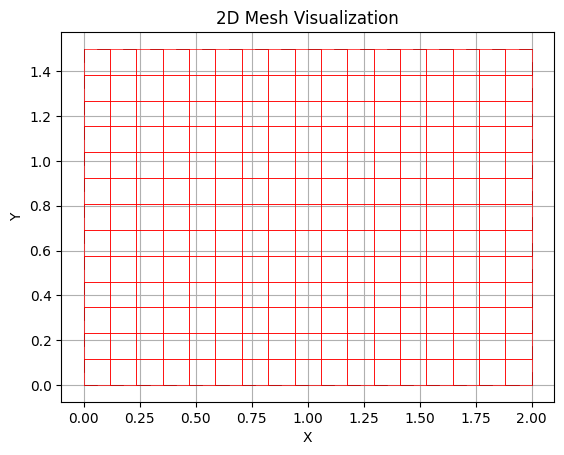


Number of nodes : 724
Available boundaries : ['bottom', 'right', 'top', 'left']


In [5]:
# ── Load mesh ─────────────────────────────────────────────────────────────
nodes, elements, boundaries = pycafe.load_mesh(
    MSH_FILE, show_info=True, show_plot=True
)

n_nodes = nodes.shape[0]
print(f"\nNumber of nodes : {n_nodes}")
print(f"Available boundaries : {list(boundaries.keys())}")

In [6]:
# ── Boundary conditions: all hard walls (Neumann — no Dirichlet) ──────────
#
# The rigid wall condition ∂p/∂n = 0 is the natural BC of the weak
# formulation.  It requires no explicit enforcement: simply leave
# the bc_pressure_zero list empty.
#
bc = (
    [],          # bc_pressure_zero  : boundaries with p = 0 (Dirichlet)
    [],          # bc_pressure_const : boundaries with constant p
    0.0,         # pressure_const_value
    [],          # boundary_nodes_impedance
    0.0,         # Z_impedance
    [],          # bc_velocity : boundaries with imposed normal velocity
    0.0,         # value_velocity_normal
    None,        # source_node
    0.0,         # source_pressure_value
)

# ── Assemble system matrices ───────────────────────────────────────────────
system = pycafe.prepare_acoustic_system(
    nodes=nodes,
    elements=elements,
    boundaries=boundaries,
    rho=rho,
    c0=c0,
    bc=bc,
    debug=False,
)

K_red = system["K_red"]
M_red = system["M_red"]

print(f"Reduced system size : {K_red.shape[0]} DOF  "
      f"(= total nodes because no Dirichlet BCs)")

Detected acoustic element type: CQUAD8
Reduced system size : 724 DOF  (= total nodes because no Dirichlet BCs)


In [7]:
# ── Solve generalised eigenvalue problem ──────────────────────────────────
#
# For an all-Neumann cavity the stiffness matrix K is singular: the
# uniform-pressure (rigid-body) mode has λ = 0.  Numerical round-off can
# produce a tiny positive λ that survives the internal tol_eig filter and
# appears as f ≈ 0 Hz.  We therefore request a few extra modes and discard
# any frequency below 1 Hz before taking the first N_MODES physical modes.
#
_raw_freqs, _raw_modes = solve_modal_acoustic_reduced(
    K_red,
    M_red,
    num_modes=N_MODES + 4,   # buffer for possible rigid-body leakage
)

_physical = _raw_freqs > 1.0   # f < 1 Hz → rigid-body / spurious mode
freqs_fem  = _raw_freqs[_physical][:N_MODES]
modes_red  = _raw_modes[:, _physical][:, :N_MODES]

print(f"Physical modes found (f > 1 Hz): {np.sum(_physical)}")
print()
print("FEM eigenfrequencies (physical modes only):")
for i, f in enumerate(freqs_fem):
    print(f"  Mode {i+1:2d}  {f:10.4f} Hz")


Physical modes found (f > 1 Hz): 19

FEM eigenfrequencies (physical modes only):
  Mode  1     85.7501 Hz
  Mode  2    114.3336 Hz
  Mode  3    142.9169 Hz
  Mode  4    171.5022 Hz
  Mode  5    206.1193 Hz
  Mode  6    228.6752 Hz
  Mode  7    244.2242 Hz
  Mode  8    257.2666 Hz
  Mode  9    281.5285 Hz
  Mode 10    285.8416 Hz
  Mode 11    343.0641 Hz
  Mode 12    343.0692 Hz
  Mode 13    344.2074 Hz
  Mode 14    353.6185 Hz
  Mode 15    361.6195 Hz


---
## 6 — Comparison: FEM vs analytical

The table below compares the FEM eigenfrequencies (sorted in ascending order) with the exact analytical values.
The relative error is defined as:

$$\varepsilon_{\text{rel}} = \frac{|f_{\text{FEM}} - f_{\text{analytical}}|}{f_{\text{analytical}}} \times 100 \%$$

In [8]:
n_compare = min(N_MODES, len(freqs_fem))

rel_errors = (np.abs(freqs_fem[:n_compare] - analytic_freqs[:n_compare])
              / analytic_freqs[:n_compare] * 100.0)

print(f"{'Mode':>6}  {'(m,n)':>7}  {'Analytical [Hz]':>17}  "
      f"{'FEM [Hz]':>12}  {'Rel. error [%]':>15}")
print("-" * 66)
for i in range(n_compare):
    mark = " ✓" if rel_errors[i] < 1.0 else ("  " if rel_errors[i] < 5.0 else " !")
    print(f"  {i+1:>4}  {analytic_labels[i]:>7}  "
          f"{analytic_freqs[i]:>17.4f}  "
          f"{freqs_fem[i]:>12.4f}  "
          f"{rel_errors[i]:>14.4f}{mark}")

print()
print(f"Mean relative error   : {rel_errors.mean():.4f} %")
print(f"Maximum relative error: {rel_errors.max():.4f} %")
print(f"Modes with error < 1% : {np.sum(rel_errors < 1.0)}/{n_compare}")


  Mode    (m,n)    Analytical [Hz]      FEM [Hz]   Rel. error [%]
------------------------------------------------------------------
     1    (1,0)            85.7500       85.7501          0.0001 ✓
     2    (0,1)           114.3333      114.3336          0.0002 ✓
     3    (1,1)           142.9167      142.9169          0.0002 ✓
     4    (2,0)           171.5000      171.5022          0.0013 ✓
     5    (2,1)           206.1173      206.1193          0.0010 ✓
     6    (0,2)           228.6667      228.6752          0.0037 ✓
     7    (1,2)           244.2161      244.2242          0.0033 ✓
     8    (3,0)           257.2500      257.2666          0.0065 ✓
     9    (3,1)           281.5132      281.5285          0.0054 ✓
    10    (2,2)           285.8333      285.8416          0.0029 ✓
    11    (0,3)           343.0000      343.0641          0.0187 ✓
    12    (4,0)           343.0000      343.0692          0.0202 ✓
    13    (3,2)           344.1889      344.2074          0.005

---
## 7 — Visualisation of relative errors

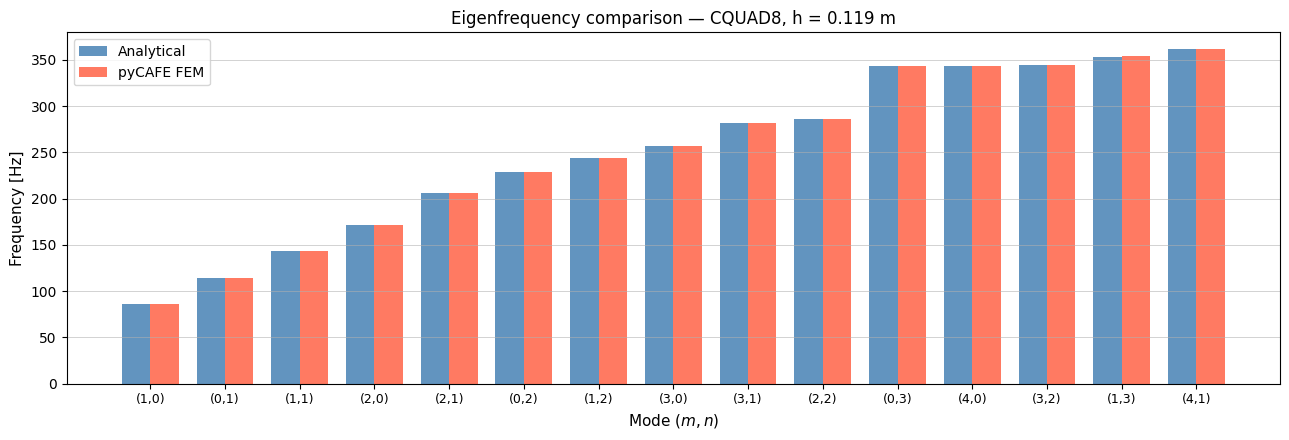

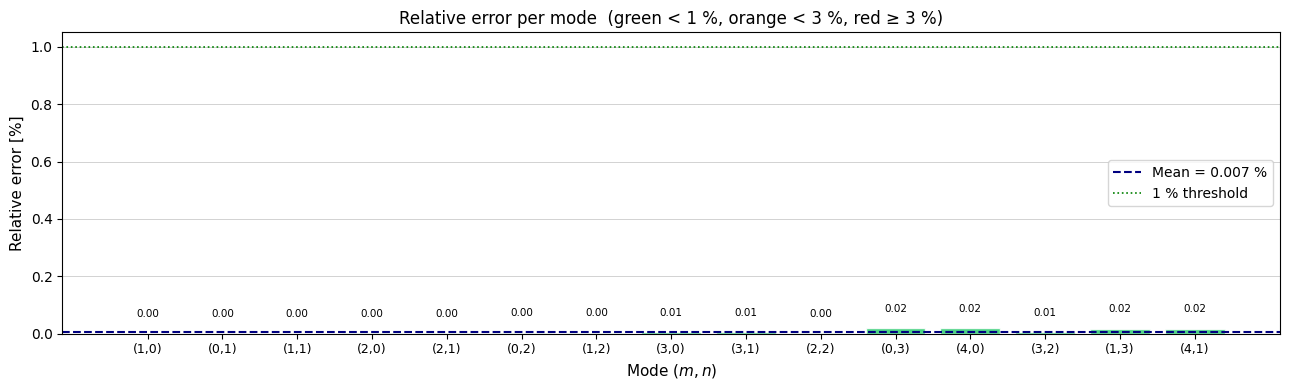

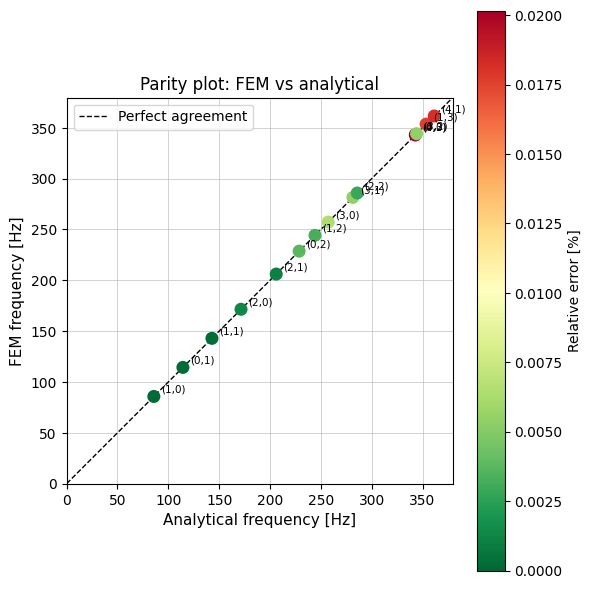

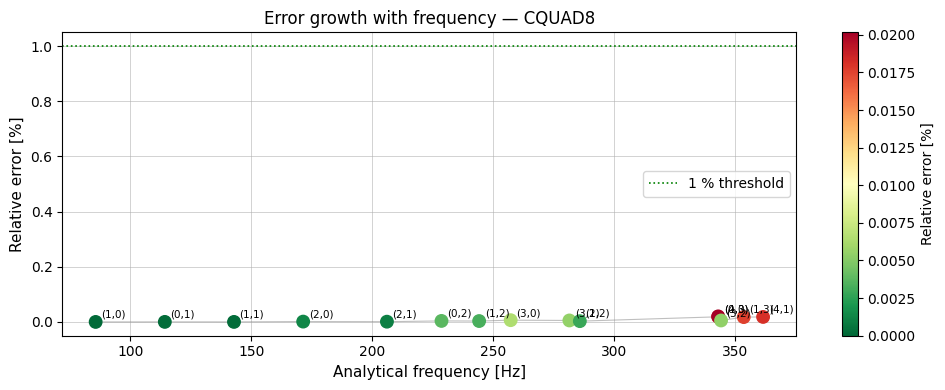

In [9]:
# ── Figure 1: frequency comparison (analytical vs FEM) ───────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))
x = np.arange(n_compare)
w = 0.38
ax.bar(x - w/2, analytic_freqs[:n_compare], width=w,
       label="Analytical", color="steelblue", alpha=0.85)
ax.bar(x + w/2, freqs_fem[:n_compare],       width=w,
       label="pyCAFE FEM", color="tomato",    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(analytic_labels[:n_compare], fontsize=9)
ax.set_xlabel("Mode $(m,n)$", fontsize=11)
ax.set_ylabel("Frequency [Hz]", fontsize=11)
ax.set_title(f"Eigenfrequency comparison — CQUAD8, h = {h_main:.3f} m", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linewidth=0.4)
plt.tight_layout()
plt.show()

# ── Figure 2: relative error histogram ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
colors = ["#2ecc71" if e < 1.0 else ("#f39c12" if e < 3.0 else "#e74c3c")
          for e in rel_errors]
bars = ax.bar(x, rel_errors, color=colors, alpha=0.85, edgecolor="white")
ax.axhline(rel_errors.mean(), color="navy", linestyle="--", linewidth=1.5,
           label=f"Mean = {rel_errors.mean():.3f} %")
ax.axhline(1.0, color="green", linestyle=":", linewidth=1.2, label="1 % threshold")
for bar, err in zip(bars, rel_errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{err:.2f}", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(analytic_labels[:n_compare], fontsize=9)
ax.set_xlabel("Mode $(m,n)$", fontsize=11)
ax.set_ylabel("Relative error [%]", fontsize=11)
ax.set_title("Relative error per mode  (green < 1 %, orange < 3 %, red ≥ 3 %)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linewidth=0.4)
plt.tight_layout()
plt.show()

# ── Figure 3: parity plot (FEM vs analytical) ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(analytic_freqs[:n_compare], freqs_fem[:n_compare],
           c=rel_errors, cmap="RdYlGn_r", s=70, zorder=3,
           vmin=0, vmax=rel_errors.max())
lim_lo = 0
lim_hi = analytic_freqs[:n_compare].max() * 1.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", linewidth=1.0,
        label="Perfect agreement")
for i in range(n_compare):
    ax.annotate(analytic_labels[i],
                (analytic_freqs[i], freqs_fem[i]),
                textcoords="offset points", xytext=(5, 3), fontsize=7.5)
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r",
                            norm=plt.Normalize(0, rel_errors.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Relative error [%]")
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_aspect("equal")
ax.set_xlabel("Analytical frequency [Hz]", fontsize=11)
ax.set_ylabel("FEM frequency [Hz]", fontsize=11)
ax.set_title("Parity plot: FEM vs analytical", fontsize=12)
ax.legend(fontsize=10)
ax.grid(linewidth=0.4)
plt.tight_layout()
plt.show()

# ── Figure 4: error vs mode frequency (scatter) ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sc = ax.scatter(analytic_freqs[:n_compare], rel_errors,
                c=rel_errors, cmap="RdYlGn_r", s=80,
                vmin=0, vmax=rel_errors.max(), zorder=3)
ax.plot(analytic_freqs[:n_compare], rel_errors,
        color="gray", linewidth=0.8, linestyle="-", alpha=0.5)
ax.axhline(1.0, color="green", linestyle=":", linewidth=1.2, label="1 % threshold")
for i in range(n_compare):
    ax.annotate(analytic_labels[i],
                (analytic_freqs[i], rel_errors[i]),
                textcoords="offset points", xytext=(4, 3), fontsize=7.5)
plt.colorbar(sc, ax=ax, label="Relative error [%]")
ax.set_xlabel("Analytical frequency [Hz]", fontsize=11)
ax.set_ylabel("Relative error [%]", fontsize=11)
ax.set_title("Error growth with frequency — CQUAD8", fontsize=12)
ax.legend(fontsize=10)
ax.grid(linewidth=0.4)
plt.tight_layout()
plt.show()


---
## 8 — Mode shape comparison

The FEM mode shapes are compared visually against the analytical cosine product $\Phi_{mn}(x,y) = \cos(m\pi x/L_x)\cos(n\pi y/L_y)$.
Amplitudes are normalised to $[-1, 1]$ for display purposes.

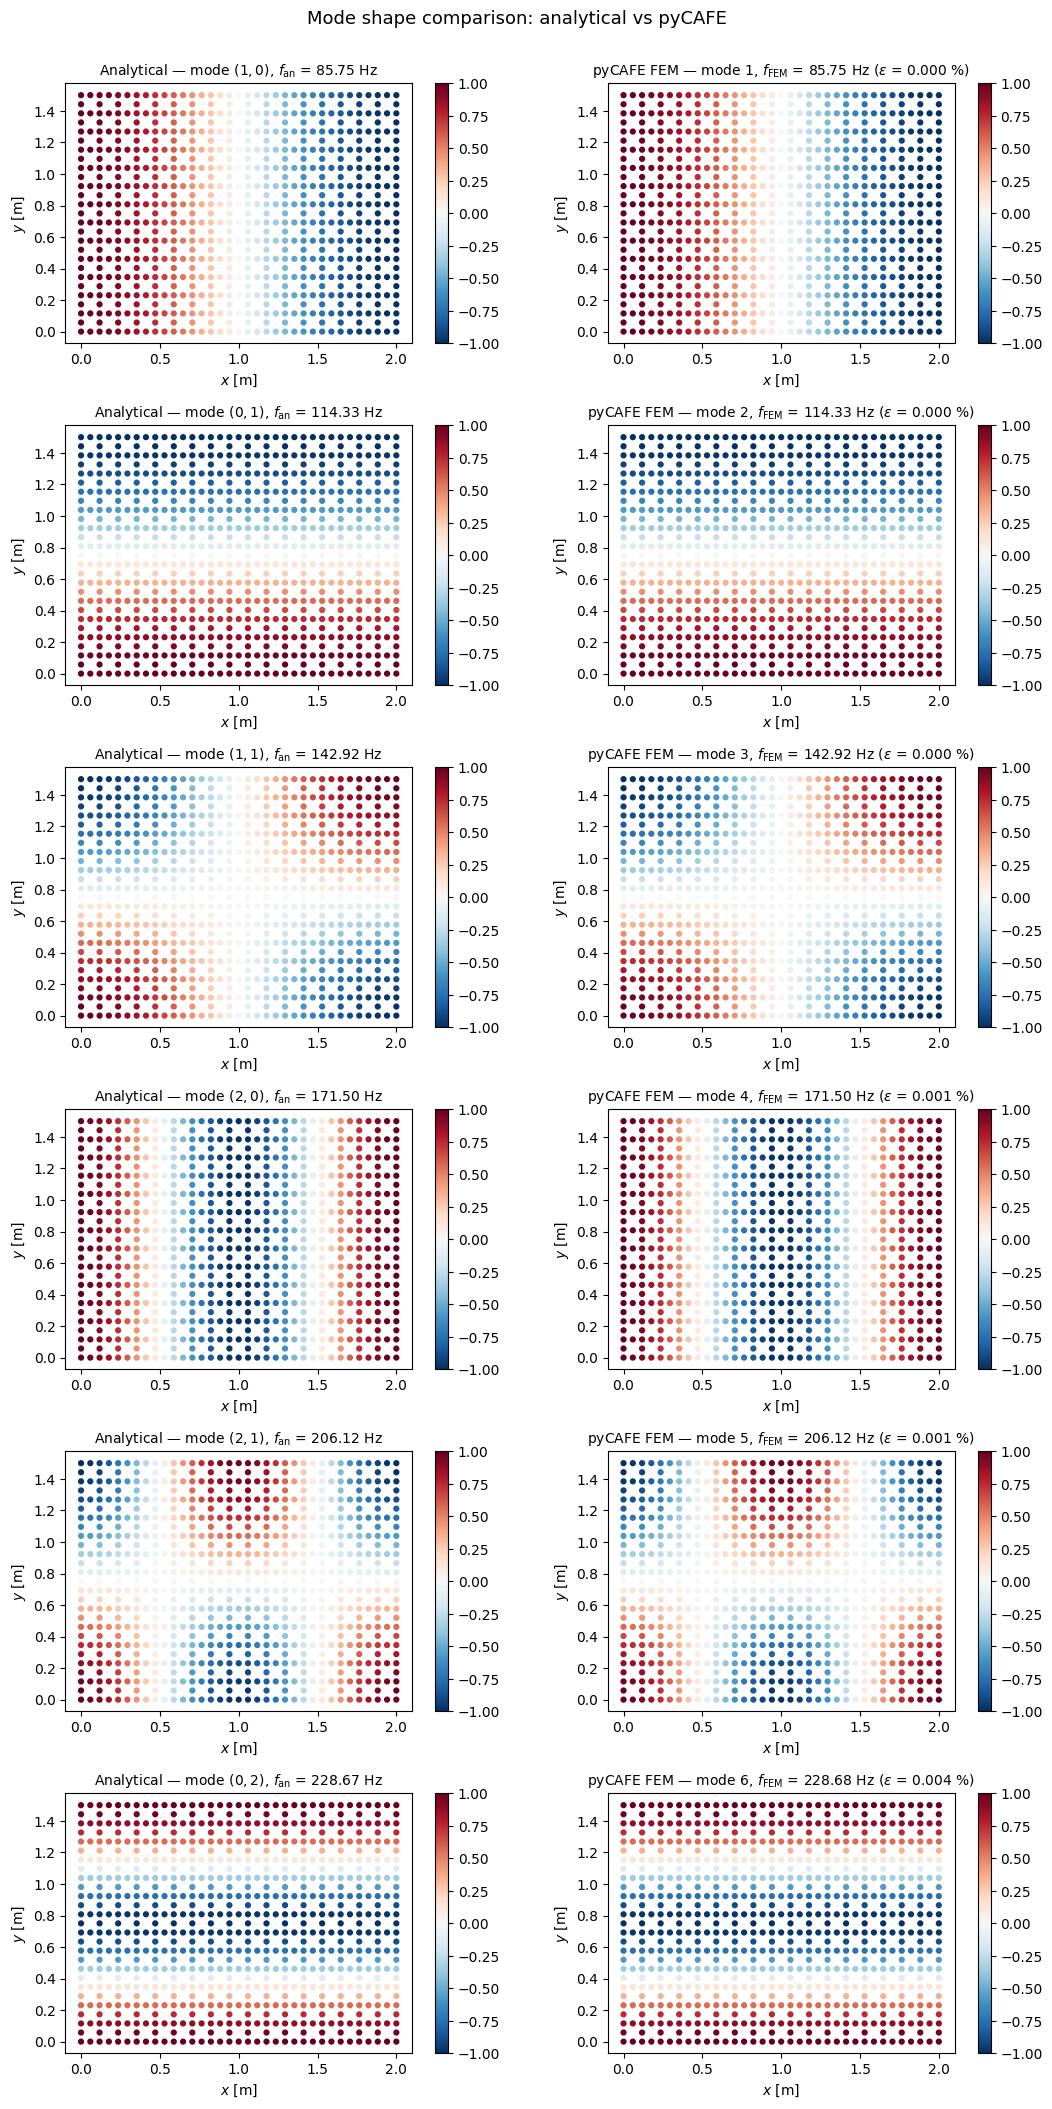

Figure saved: validation_mode_shapes.png


In [10]:
N_DISPLAY = min(6, n_compare)   # number of modes to display

fig, axes = plt.subplots(N_DISPLAY, 2,
                         figsize=(11, 3.5 * N_DISPLAY),
                         squeeze=False)

for i in range(N_DISPLAY):
    _, m, n = analytic_modes[i]

    # ── FEM mode shape ──────────────────────────────────────────────────
    mode_full = expand_mode_to_full(
        modes_red[:, i],
        system["idx_free"],
        system["p0_nodes"],
        n_nodes,
    )
    phi_fem = np.real(mode_full)
    if np.max(np.abs(phi_fem)) > 0:
        phi_fem /= np.max(np.abs(phi_fem))

    # ── Analytical mode shape ───────────────────────────────────────────
    phi_an = (np.cos(m * np.pi * nodes[:, 0] / Lx)
              * np.cos(n * np.pi * nodes[:, 1] / Ly))

    # sign alignment (dot-product check)
    if np.dot(phi_fem, phi_an) < 0:
        phi_fem = -phi_fem

    kw = dict(cmap="RdBu_r", vmin=-1, vmax=1, s=12)

    ax_l = axes[i][0]
    ax_r = axes[i][1]

    sc = ax_l.scatter(nodes[:, 0], nodes[:, 1], c=phi_an, **kw)
    ax_l.set_aspect("equal")
    ax_l.set_title(f"Analytical — mode $({m},{n})$, "
                   f"$f_{{\\mathrm{{an}}}}$ = {analytic_freqs[i]:.2f} Hz",
                   fontsize=10)
    ax_l.set_xlabel("$x$ [m]"); ax_l.set_ylabel("$y$ [m]")
    plt.colorbar(sc, ax=ax_l)

    sc = ax_r.scatter(nodes[:, 0], nodes[:, 1], c=phi_fem, **kw)
    ax_r.set_aspect("equal")
    ax_r.set_title(f"pyCAFE FEM — mode {i+1}, "
                   f"$f_{{\\mathrm{{FEM}}}}$ = {freqs_fem[i]:.2f} Hz "
                   f"($\\varepsilon$ = {rel_errors[i]:.3f} %)",
                   fontsize=10)
    ax_r.set_xlabel("$x$ [m]"); ax_r.set_ylabel("$y$ [m]")
    plt.colorbar(sc, ax=ax_r)

fig.suptitle("Mode shape comparison: analytical vs pyCAFE",
             fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig("validation_mode_shapes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: validation_mode_shapes.png")

---
## 9 — Mesh convergence study

The relative error is computed for the **first 6 physical eigenfrequencies** over a
sequence of progressively finer meshes, for both **CQUAD4** (first-order) and
**CQUAD8** (second-order) elements.

For a $p$-th order element the eigenfrequency error converges as [3]:

$$\varepsilon_{\text{rel}} \propto h^{2p}$$

Expected rates:
- CQUAD4 ($p=1$): $\mathcal{O}(h^2)$  
- CQUAD8 ($p=2$): $\mathcal{O}(h^4)$


In [11]:
# First 6 analytical reference frequencies and labels
N_CONV = 6
conv_ref_freqs  = analytic_freqs[:N_CONV]
conv_ref_labels = analytic_labels[:N_CONV]

print("Reference modes for convergence study:")
for i, (f, lbl) in enumerate(zip(conv_ref_freqs, conv_ref_labels)):
    print(f"  Mode {i+1}  {lbl:>7}  {f:.4f} Hz")
print()

# Mesh sizes: log-spaced from coarse to fine
h_values = np.array([0.60, 0.45, 0.30, 0.20, 0.14, 0.10, 0.07, 0.05])


def run_convergence_multi(h_vals, elem_order, n_modes=N_CONV):
    """
    For each h, solve modal analysis and return:
      ndofs  : (n_h,)          number of nodes
      errors : (n_h, n_modes)  relative errors [%] for each mode
    """
    label = "CQUAD8" if elem_order == 2 else "CQUAD4"
    ndofs_list  = []
    errors_list = []   # list of (n_modes,) arrays

    header = f"  {'h':>5}  {'nodes':>6}  " + "  ".join(
        f"{lbl:>9}" for lbl in conv_ref_labels)
    print(f"{'='*len(header)}")
    print(f"  {label}")
    print(f"{'='*len(header)}")
    print(header)
    print("-" * len(header))

    for h in h_vals:
        msh = f"_conv_{label}_h{h:.2f}.msh"
        make_rectangle_mesh(Lx, Ly, h=h, elem_order=elem_order, filename=msh)

        nd, el, bd = pycafe.load_mesh(msh, show_info=False, show_plot=False)
        bc_c = ([], [], 0.0, [], 0.0, [], 0.0, None, 0.0)
        sys_c = pycafe.prepare_acoustic_system(
            nodes=nd, elements=el, boundaries=bd,
            rho=rho, c0=c0, bc=bc_c, debug=False,
        )

        raw_f, _ = solve_modal_acoustic_reduced(
            sys_c["K_red"], sys_c["M_red"], num_modes=n_modes + 4
        )
        phys = raw_f[raw_f > 1.0][:n_modes]

        if len(phys) < n_modes:
            print(f"  {h:>5.2f}  WARNING: only {len(phys)} physical modes found")
            pathlib.Path(msh).unlink(missing_ok=True)
            continue

        errs = np.abs(phys - conv_ref_freqs) / conv_ref_freqs * 100.0
        ndofs_list.append(nd.shape[0])
        errors_list.append(errs)

        row = f"  {h:>5.2f}  {nd.shape[0]:>6}  " + "  ".join(
            f"{e:>8.3f}%" for e in errs)
        print(row)

        pathlib.Path(msh).unlink(missing_ok=True)

    print()
    return np.array(ndofs_list), np.vstack(errors_list)


ndofs_q4, errors_q4 = run_convergence_multi(h_values, elem_order=1)
ndofs_q8, errors_q8 = run_convergence_multi(h_values, elem_order=2)


Reference modes for convergence study:
  Mode 1    (1,0)  85.7500 Hz
  Mode 2    (0,1)  114.3333 Hz
  Mode 3    (1,1)  142.9167 Hz
  Mode 4    (2,0)  171.5000 Hz
  Mode 5    (2,1)  206.1173 Hz
  Mode 6    (0,2)  228.6667 Hz

  CQUAD4
      h   nodes      (1,0)      (0,1)      (1,1)      (2,0)      (2,1)      (0,2)
---------------------------------------------------------------------------------
Info    : Reading '_conv_CQUAD4_h0.60.msh'...
Info    : 9 entities
Info    : 12 nodes
Info    : 16 elements
Info    : Done reading '_conv_CQUAD4_h0.60.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 10
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 6
Detected acoustic element type: CQUAD4
   0.60      12     4.607%    10.266%     8.263%    16.955%    14.938%    10.266%
Info    : Reading '_conv_CQUAD4_h0.45.msh'...
Info    : 9 entities
Info    : 20 nodes
Info    : 26 elements
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 14
→ Quadrilateral 4 | 

Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized


   0.07     660     0.049%     0.093%     0.077%     0.196%     0.164%     0.373%
Info    : Reading '_conv_CQUAD4_h0.05.msh'...
Info    : 9 entities
Info    : 1271 nodes
Info    : 1340 elements
Info    : Done reading '_conv_CQUAD4_h0.05.msh'
→ Line 2          | Dim: 1 | Order: 1 | Nodes/Elem: 2 | Count: 140
→ Quadrilateral 4 | Dim: 2 | Order: 1 | Nodes/Elem: 4 | Count: 1200
Detected acoustic element type: CQUAD4


Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized


   0.05    1271     0.026%     0.046%     0.039%     0.103%     0.085%     0.183%

  CQUAD8
      h   nodes      (1,0)      (0,1)      (1,1)      (2,0)      (2,1)      (0,2)
---------------------------------------------------------------------------------
Info    : Reading '_conv_CQUAD8_h0.60.msh'...
Info    : 9 entities
Info    : 29 nodes
Info    : 16 elements
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 10
Info    : Done reading '_conv_CQUAD8_h0.60.msh'
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 6
Detected acoustic element type: CQUAD8
   0.60      29     0.079%     0.375%     0.313%     1.089%     1.300%    10.266%
Info    : Reading '_conv_CQUAD8_h0.45.msh'...
Info    : 9 entities
Info    : 51 nodes
Info    : 26 elements
Info    : Done reading '_conv_CQUAD8_h0.45.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 14
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 12
Detected acoustic element type: CQUAD8
   0.45  

...

   0.10     971     0.000%     0.000%     0.000%     0.001%     0.001%     0.002%
Info    : Reading '_conv_CQUAD8_h0.07.msh'...
Info    : 9 entities
Info    : 1928 nodes
Info    : 709 elements
Info    : Done reading '_conv_CQUAD8_h0.07.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 100
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 609
Detected acoustic element type: CQUAD8


Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized


   0.07    1928     0.000%     0.000%     0.000%     0.000%     0.000%     0.001%
Info    : Reading '_conv_CQUAD8_h0.05.msh'...
Info    : 9 entities
Info    : 3741 nodes
Info    : 1340 elements
Info    : Done reading '_conv_CQUAD8_h0.05.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 140
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 1200
Detected acoustic element type: CQUAD8


Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized


   0.05    3741     0.000%     0.000%     0.000%     0.000%     0.000%     0.000%



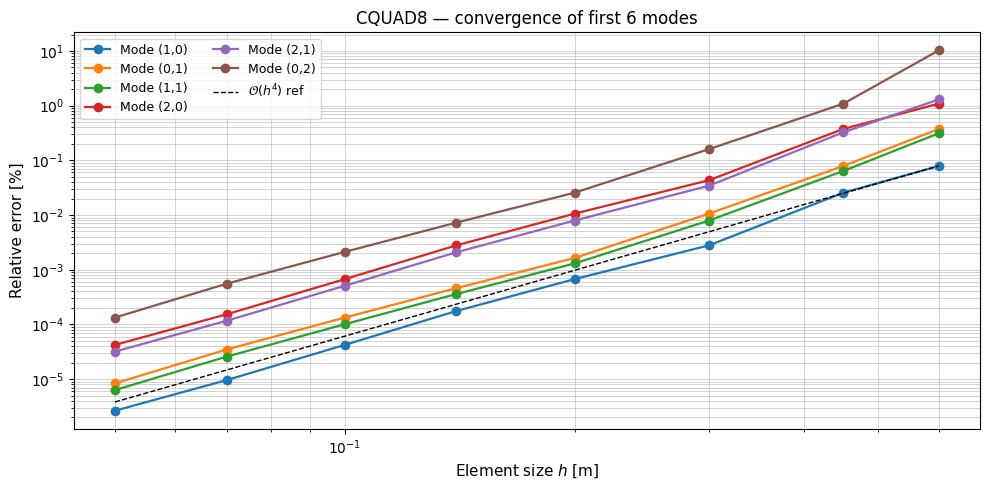

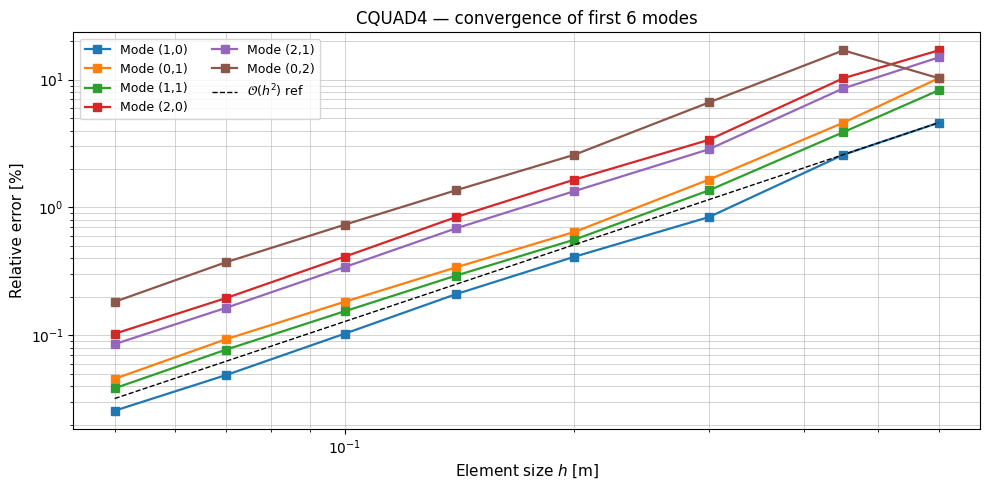

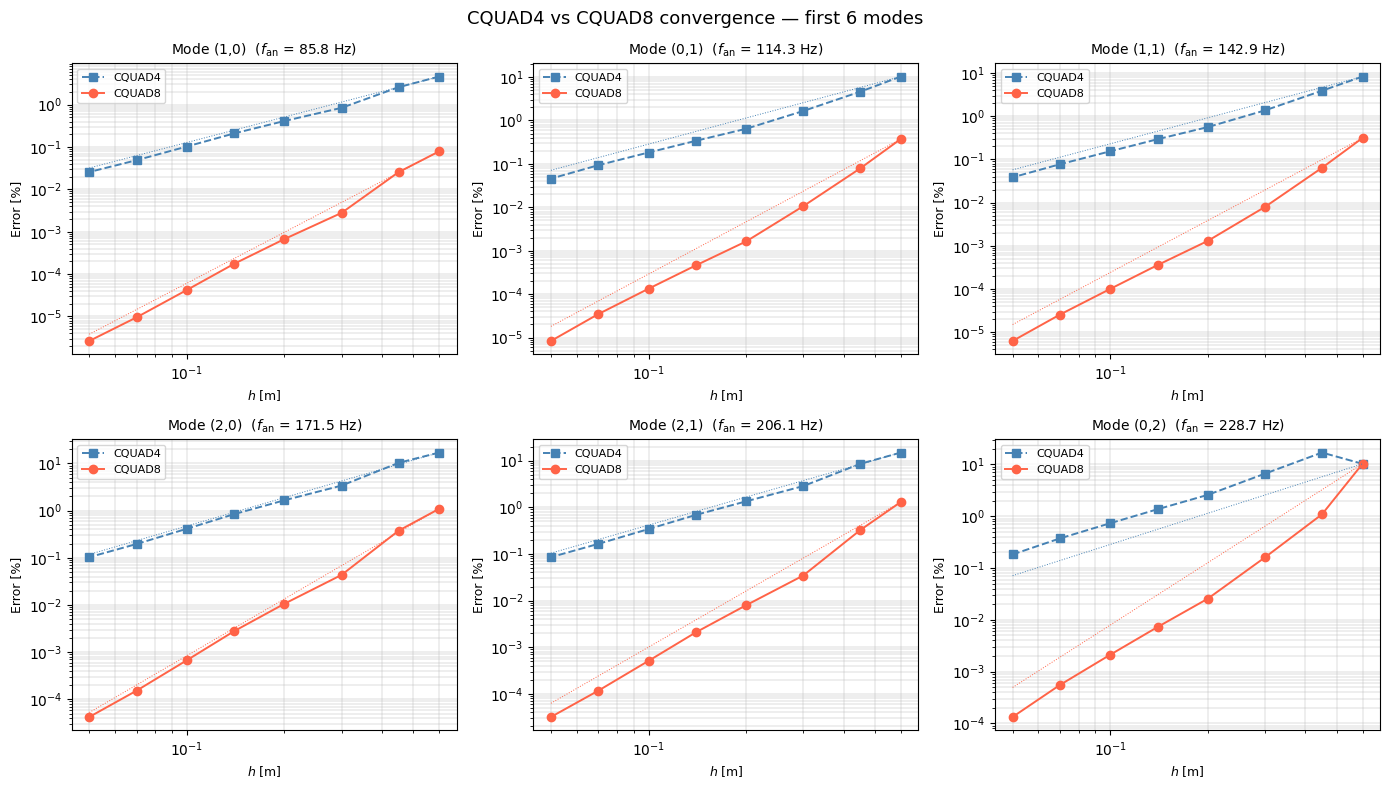

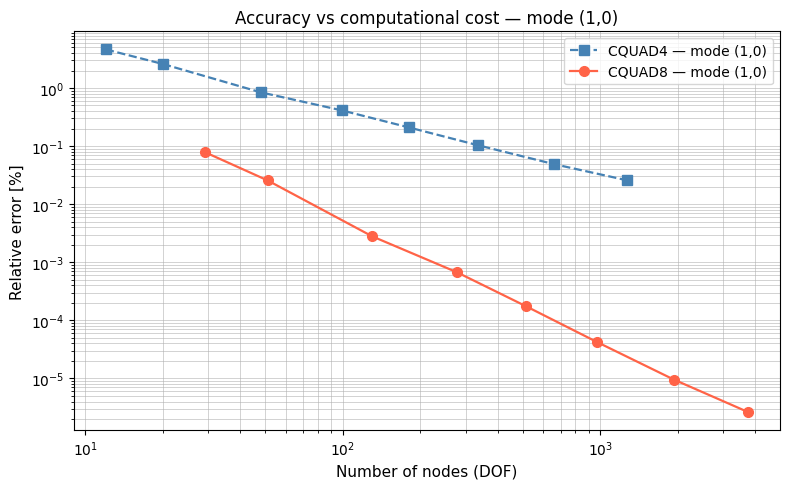

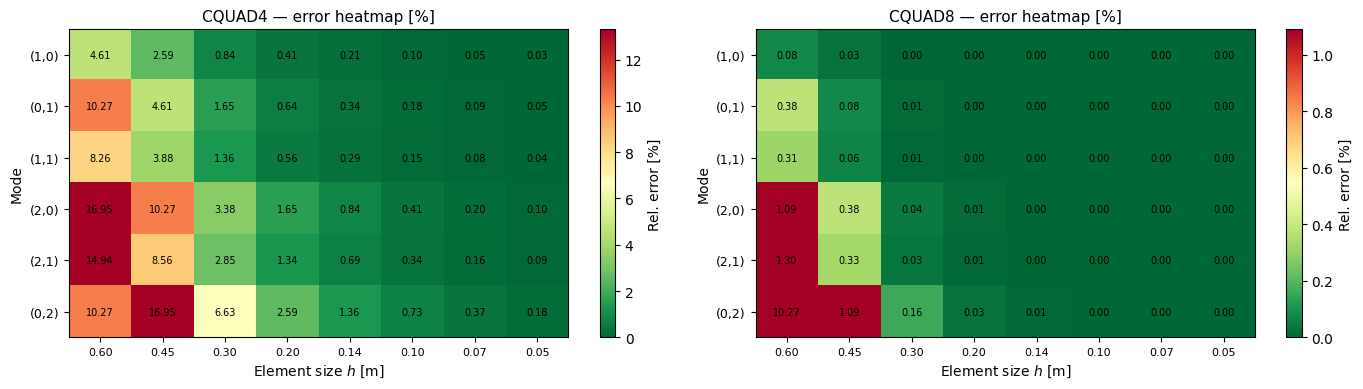

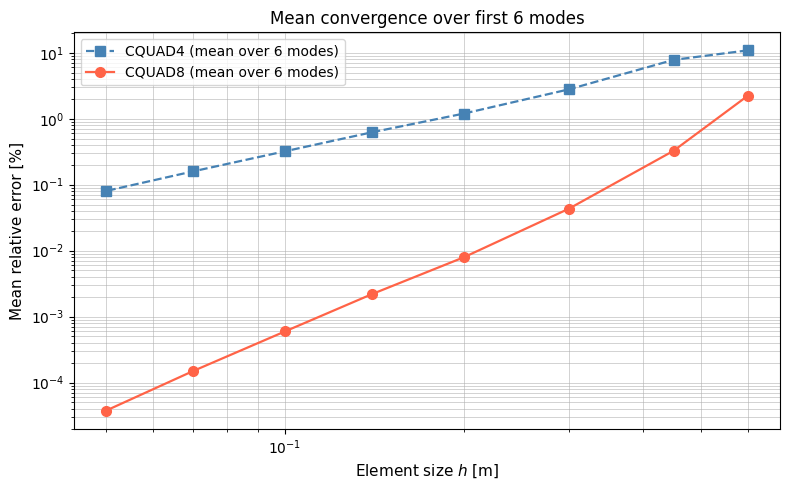

In [12]:
colors6 = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"]

# ── Figure A: CQUAD8 — error vs h, one curve per mode ────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(N_CONV):
    ax.loglog(h_values[:len(ndofs_q8)], errors_q8[:, i],
              "o-", color=colors6[i], markersize=6, linewidth=1.6,
              label=f"Mode {conv_ref_labels[i]}")
# O(h^4) reference
h_line = np.array([h_values[-1], h_values[0]])
e0 = errors_q8[0, 0]
ax.loglog(h_line, e0 * (h_line / h_values[0])**4,
          "k--", linewidth=1.0, label=r"$\mathcal{O}(h^4)$ ref")
ax.set_xlabel("Element size $h$ [m]", fontsize=11)
ax.set_ylabel("Relative error [%]", fontsize=11)
ax.set_title("CQUAD8 — convergence of first 6 modes", fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, which="both", linewidth=0.4)
plt.tight_layout()
plt.show()

# ── Figure B: CQUAD4 — error vs h, one curve per mode ────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(N_CONV):
    ax.loglog(h_values[:len(ndofs_q4)], errors_q4[:, i],
              "s-", color=colors6[i], markersize=6, linewidth=1.6,
              label=f"Mode {conv_ref_labels[i]}")
e0 = errors_q4[0, 0]
ax.loglog(h_line, e0 * (h_line / h_values[0])**2,
          "k--", linewidth=1.0, label=r"$\mathcal{O}(h^2)$ ref")
ax.set_xlabel("Element size $h$ [m]", fontsize=11)
ax.set_ylabel("Relative error [%]", fontsize=11)
ax.set_title("CQUAD4 — convergence of first 6 modes", fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, which="both", linewidth=0.4)
plt.tight_layout()
plt.show()

# ── Figure C: CQUAD4 vs CQUAD8 for each mode — 2×3 subplots ─────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=False, sharey=False)
for i, ax in enumerate(axes.flat):
    ax.loglog(h_values[:len(ndofs_q4)], errors_q4[:, i],
              "s--", color="steelblue", markersize=6, linewidth=1.4,
              label="CQUAD4")
    ax.loglog(h_values[:len(ndofs_q8)], errors_q8[:, i],
              "o-",  color="tomato",    markersize=6, linewidth=1.4,
              label="CQUAD8")
    # theoretical slopes
    h_l = np.array([h_values[-1], h_values[0]])
    ax.loglog(h_l, errors_q4[0, i] * (h_l / h_values[0])**2,
              color="steelblue", linewidth=0.7, linestyle=":")
    ax.loglog(h_l, errors_q8[0, i] * (h_l / h_values[0])**4,
              color="tomato",    linewidth=0.7, linestyle=":")
    ax.set_title(f"Mode {conv_ref_labels[i]}  "
                 f"($f_{{\mathrm{{an}}}}$ = {conv_ref_freqs[i]:.1f} Hz)",
                 fontsize=10)
    ax.set_xlabel("$h$ [m]", fontsize=9)
    ax.set_ylabel("Error [%]", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", linewidth=0.3)
fig.suptitle("CQUAD4 vs CQUAD8 convergence — first 6 modes", fontsize=13)
plt.tight_layout()
plt.show()

# ── Figure D: error vs DOFs — CQUAD4 vs CQUAD8, mode (1,0) only ──────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ndofs_q4, errors_q4[:, 0],
          "s--", color="steelblue", markersize=7, linewidth=1.6,
          label="CQUAD4 — mode (1,0)")
ax.loglog(ndofs_q8, errors_q8[:, 0],
          "o-",  color="tomato",    markersize=7, linewidth=1.6,
          label="CQUAD8 — mode (1,0)")
ax.set_xlabel("Number of nodes (DOF)", fontsize=11)
ax.set_ylabel("Relative error [%]", fontsize=11)
ax.set_title("Accuracy vs computational cost — mode (1,0)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which="both", linewidth=0.4)
plt.tight_layout()
plt.show()

# ── Figure E: error heatmap — CQUAD8, modes × h ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (err_mat, lbl) in zip(
        axes, [(errors_q4, "CQUAD4"), (errors_q8, "CQUAD8")]):
    h_used = h_values[:err_mat.shape[0]]
    im = ax.imshow(err_mat.T, aspect="auto", cmap="RdYlGn_r",
                   vmin=0, vmax=np.percentile(err_mat, 95))
    ax.set_xticks(range(len(h_used)))
    ax.set_xticklabels([f"{h:.2f}" for h in h_used], fontsize=8)
    ax.set_yticks(range(N_CONV))
    ax.set_yticklabels(conv_ref_labels, fontsize=9)
    ax.set_xlabel("Element size $h$ [m]", fontsize=10)
    ax.set_ylabel("Mode", fontsize=10)
    ax.set_title(f"{lbl} — error heatmap [%]", fontsize=11)
    for ii in range(err_mat.shape[0]):
        for jj in range(N_CONV):
            ax.text(ii, jj, f"{err_mat[ii, jj]:.2f}",
                    ha="center", va="center", fontsize=7,
                    color="black")
    plt.colorbar(im, ax=ax, label="Rel. error [%]")
plt.tight_layout()
plt.show()

# ── Figure F: mean error vs h — CQUAD4 vs CQUAD8 ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(h_values[:len(ndofs_q4)], errors_q4.mean(axis=1),
          "s--", color="steelblue", markersize=7, linewidth=1.6,
          label="CQUAD4 (mean over 6 modes)")
ax.loglog(h_values[:len(ndofs_q8)], errors_q8.mean(axis=1),
          "o-",  color="tomato",    markersize=7, linewidth=1.6,
          label="CQUAD8 (mean over 6 modes)")
ax.set_xlabel("Element size $h$ [m]", fontsize=11)
ax.set_ylabel("Mean relative error [%]", fontsize=11)
ax.set_title("Mean convergence over first 6 modes", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which="both", linewidth=0.4)
plt.tight_layout()
plt.show()


---
## 10 — Comparison with VIBRA (ACT_QUADRANGLE_8)

VIBRA ([MOPT-UFSC/VIBRA](https://github.com/MOPT-UFSC/VIBRA)) is an open-source Python vibroacoustic FEM framework developed at UFSC (Brazil). It implements an independent `ACT_QUADRANGLE_8` element with 2×2 Gauss quadrature.

The comparison below assembles **K** and **M** using VIBRA's element formulation on the **same mesh** as pyCAFE, then solves the same generalised eigenvalue problem. Differences reveal implementation choices (shape function ordering, integration scheme) rather than meshing effects.

The VIBRA element code is used **standalone** (only numpy required) — no full VIBRA installation needed.

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# VIBRA ACT_QUADRANGLE_8 — standalone extraction (numpy only)
# Source: https://github.com/MOPT-UFSC/VIBRA
#         vibra/engine/elements/elements_2d/acoustic/acoustic_quad8_element.py
#         vibra/engine/elements/surface_elements.py
# Adapted for standalone use without the full VIBRA framework.
# ═══════════════════════════════════════════════════════════════════════════

class _VIBRA_QUAD8:
    """
    Self-contained copy of VIBRA's ACT_QUADRANGLE_8 acoustic element.
    Returns integrated stiffness (BtB) and mass (NtN) matrices for all
    elements in stacked form.

    Reference: Atalla & Sgard, 'Finite Element and Boundary Methods in
    Structural Acoustics and Vibration', 2015, p. 174.
    """

    NODES_PER_ELEMENT = 8
    DOF_PER_NODE      = 1
    DOF_PER_ELEMENT   = 8

    def __init__(self, nodal_coordinates, connectivities):
        """
        Parameters
        ----------
        nodal_coordinates : (N_nodes, 4) array  — columns: [id, x, y, z]
        connectivities    : (N_elem,  8) int array — 0-based node indices
        """
        self.nodal_coordinates = np.asarray(nodal_coordinates, dtype=float)
        self.connectivities    = np.asarray(connectivities,    dtype=int)
        self._define_integration_points(4)          # 2×2 Gauss
        self._process_shape_functions()

    # ── integration points (VIBRA, surface_elements.py) ──────────────────
    def _define_integration_points(self, nint=4):
        a  = 1.0 / np.sqrt(3)
        self.num_int_data = np.array([
            [-a, -a, 1.0],
            [ a, -a, 1.0],
            [ a,  a, 1.0],
            [-a,  a, 1.0],
        ], dtype=float)
        self.nint = nint
        self.wps  = self.num_int_data[:, -1].reshape(-1, 1, 1)

    # ── shape functions (VIBRA, acoustic_quad8_element.py) ───────────────
    def _process_shape_functions(self):
        xi_1 = self.num_int_data[:, 0]
        xi_2 = self.num_int_data[:, 1]

        phi = np.zeros((self.nint, 1, 8), dtype=float)
        phi[:, 0, 0] = (1-xi_1)*(1-xi_2)*(-xi_1-xi_2-1) / 4
        phi[:, 0, 1] = (1+xi_1)*(1-xi_2)*( xi_1-xi_2-1) / 4
        phi[:, 0, 2] = (1+xi_1)*(1+xi_2)*( xi_1+xi_2-1) / 4
        phi[:, 0, 3] = (1-xi_1)*(1+xi_2)*(-xi_1+xi_2-1) / 4
        phi[:, 0, 4] = (1-xi_1**2)*(1-xi_2) / 2
        phi[:, 0, 5] = (1+xi_1)*(1-xi_2**2) / 2
        phi[:, 0, 6] = (1-xi_1**2)*(1+xi_2) / 2
        phi[:, 0, 7] = (1-xi_1)*(1-xi_2**2) / 2

        dphi = np.zeros((self.nint, 2, 8), dtype=float)
        dphi[:, 0, 0] = (1-xi_2)*(2*xi_1+xi_2) / 4
        dphi[:, 0, 1] = (1-xi_2)*(2*xi_1-xi_2) / 4
        dphi[:, 0, 2] = (1+xi_2)*(2*xi_1+xi_2) / 4
        dphi[:, 0, 3] = (1+xi_2)*(2*xi_1-xi_2) / 4
        dphi[:, 0, 4] = -(2*xi_1)*(1-xi_2) / 2
        dphi[:, 0, 5] =  (1-xi_2**2) / 2
        dphi[:, 0, 6] = -(2*xi_1)*(1+xi_2) / 2
        dphi[:, 0, 7] = -(1-xi_2**2) / 2

        dphi[:, 1, 0] = (1-xi_1)*( xi_1+2*xi_2) / 4
        dphi[:, 1, 1] = (1+xi_1)*(-xi_1+2*xi_2) / 4
        dphi[:, 1, 2] = (1+xi_1)*( xi_1+2*xi_2) / 4
        dphi[:, 1, 3] = (1-xi_1)*(-xi_1+2*xi_2) / 4
        dphi[:, 1, 4] = -(1-xi_2**2) / 2
        dphi[:, 1, 5] = -(1+xi_1)*(2*xi_2) / 2
        dphi[:, 1, 6] =  (1-xi_2**2) / 2
        dphi[:, 1, 7] = -(1-xi_1)*(2*xi_2) / 2

        self.phi  = phi
        self.dphi = dphi

    # ── local coordinates (VIBRA uses 3D coords → project to 2D) ─────────
    def _get_local_coords(self):
        nc  = self.nodal_coordinates
        con = self.connectivities
        nel = con.shape[0]

        # XYZ columns (VIBRA nodal_coordinates format: [id, x, y, z])
        xyz = nc[:, 1:4]                         # (N_nodes, 3)
        c   = xyz[con, :]                        # (nel, 8, 3)

        # local x-axis = edge 1→2
        vec_12 = c[:, 1, :] - c[:, 0, :]        # (nel, 3)
        # local z-axis = cross(x, edge 1→4)
        vec_14 = c[:, 3, :] - c[:, 0, :]
        loc_z  = np.cross(vec_12, vec_14)        # (nel, 3)
        loc_y  = np.cross(loc_z, vec_12)

        ux = vec_12 / np.linalg.norm(vec_12, axis=1, keepdims=True)
        uy = loc_y  / np.linalg.norm(loc_y,  axis=1, keepdims=True)

        # project all 8 nodes onto local (x, y)
        vecs = c - c[:, 0:1, :]                  # (nel, 8, 3)
        xloc = np.einsum('nij,nj->ni', vecs, ux)  # (nel, 8)
        yloc = np.einsum('nij,nj->ni', vecs, uy)  # (nel, 8)

        coord_loc = np.stack([xloc, yloc], axis=2)   # (nel, 8, 2)
        return coord_loc

    # ── stiffness (BtB) and mass (NtN) matrices ──────────────────────────
    def stacked_BtB_NtN(self):
        """Returns (K_stack, M_stack) each of shape (nel, 8, 8)."""
        local_coords = self._get_local_coords()   # (nel, 8, 2)

        BtB = 0.0
        NtN = 0.0

        for i in range(self.nint):
            # Jacobian: (2,8) @ (nel,8,2) → (nel,2,2)
            JAC = self.dphi[i, :, :] @ local_coords

            det = JAC[:, 0, 0]*JAC[:, 1, 1] - JAC[:, 0, 1]*JAC[:, 1, 0]
            det = det.reshape(-1, 1, 1)

            # inverse of Jacobian
            AUJJ = np.zeros_like(JAC)
            AUJJ[:, 0, 0] =  JAC[:, 1, 1]
            AUJJ[:, 0, 1] = -JAC[:, 0, 1]
            AUJJ[:, 1, 0] = -JAC[:, 1, 0]
            AUJJ[:, 1, 1] =  JAC[:, 0, 0]
            inv_JAC = AUJJ / det            # (nel, 2, 2)

            # B = invJ @ dphi:  (nel,2,2) @ (2,8) → (nel,2,8)
            B   = inv_JAC @ self.dphi[i, :, :]
            Bt  = np.transpose(B, (0, 2, 1))   # (nel,8,2)

            N   = self.phi[i, :, :]             # (1,8)
            Nt  = N.T                           # (8,1)

            BtB += Bt @ B    * (det * self.wps[i])   # (nel,8,8)
            NtN += Nt @ N    * (det * self.wps[i])

        return BtB, NtN


print("VIBRA ACT_QUADRANGLE_8 standalone class defined.")


VIBRA ACT_QUADRANGLE_8 standalone class defined.


In [14]:
import scipy.sparse as sp
from scipy.linalg import eigh

# ── helpers ───────────────────────────────────────────────────────────────
def vibra_assemble(nodes_pycafe, conn_pycafe, rho, c0):
    """
    Assemble global K and M from VIBRA's ACT_QUADRANGLE_8 element.

    nodes_pycafe : (N, 2) or (N, 3)  — pyCAFE node coordinates (0-based)
    conn_pycafe  : (E, 8) int         — 0-based connectivity (pyCAFE order)

    Returns K, M as scipy CSR sparse matrices.
    """
    n_nodes = nodes_pycafe.shape[0]

    # VIBRA nodal_coordinates format: [node_id, x, y, z]
    if nodes_pycafe.shape[1] == 2:
        z = np.zeros((n_nodes, 1))
        xyz = np.hstack([nodes_pycafe, z])
    else:
        xyz = nodes_pycafe[:, :3]

    node_id = np.arange(n_nodes).reshape(-1, 1)
    vibra_coords = np.hstack([node_id, xyz])   # (N, 4)

    # VIBRA node ordering for QUAD8 (serendipity):
    # 0→corner(-1,-1), 1→corner(+1,-1), 2→corner(+1,+1), 3→corner(-1,+1)
    # 4→mid bottom,    5→mid right,      6→mid top,        7→mid left
    #
    # pyCAFE/gmsh QUAD8 node ordering (gmsh element type 16):
    # same serendipity order as above (verified from .msh files)
    # → no reordering needed

    elem = _VIBRA_QUAD8(vibra_coords, conn_pycafe)
    BtB, NtN = elem.stacked_BtB_NtN()     # (nel, 8, 8) each

    # Physical matrices:
    #   K_e = (1/rho)  * integral(Bt B) dA
    #   M_e = (1/rho c0^2) * integral(Nt N) dA
    K_e = (1.0 / rho)         * BtB
    M_e = (1.0 / (rho*c0**2)) * NtN

    # Assembly (COO format)
    nel   = conn_pycafe.shape[0]
    ndof  = n_nodes

    # row/col indices for 8×8 blocks
    rows  = np.repeat(conn_pycafe, 8, axis=1)        # (nel, 64)
    cols  = np.tile(conn_pycafe,  (1, 8))            # (nel, 64)

    # a cleaner way: use outer product per element
    dofs  = conn_pycafe                               # (nel, 8)
    irow  = np.kron(dofs, np.ones((1,8), dtype=int)) # (nel,64)
    icol  = np.tile(dofs, (1,8))                     # (nel,64)

    K_coo = sp.coo_matrix(
        (K_e.reshape(-1), (irow.reshape(-1), icol.reshape(-1))),
        shape=(ndof, ndof)
    ).tocsr()
    M_coo = sp.coo_matrix(
        (M_e.reshape(-1), (irow.reshape(-1), icol.reshape(-1))),
        shape=(ndof, ndof)
    ).tocsr()

    return K_coo, M_coo


def vibra_modal(K, M, num_modes=N_MODES):
    """
    Solve the generalised eigenproblem K φ = λ M φ using sparse shift-invert.
    Dense eigh fails because the consistent mass matrix M has near-zero
    eigenvalues (~1e-23) that make it numerically non-positive-definite;
    the sparse eigsh with sigma handles this robustly.
    """
    from scipy.sparse.linalg import eigsh as sp_eigsh

    # Request extra modes to buffer rigid-body leakage
    k = min(num_modes + 6, K.shape[0] - 2)
    vals, _ = sp_eigsh(K, M=M, k=k, sigma=0.5, which='LM')
    freqs = np.sort(np.sqrt(np.maximum(np.real(vals), 0)) / (2*np.pi))
    return freqs[freqs > 1.0][:num_modes]


print("VIBRA assembler ready.")


VIBRA assembler ready.


In [15]:
# ── Re-use the main validation mesh already on disk ───────────────────────
nd_v, el_v, bd_v = pycafe.load_mesh(MSH_FILE, show_info=True, show_plot=False)

# extract CQUAD8 connectivity (key with 8 columns)
conn_key = [k for k, v in el_v.items() if hasattr(v, "ndim") and v.ndim==2 and v.shape[1]==8][0]
conn_q8  = el_v[conn_key] - 1          # 0-based

print(f"Nodes: {nd_v.shape[0]}  |  CQUAD8 elements: {conn_q8.shape[0]}")

# ── Assemble with VIBRA ───────────────────────────────────────────────────
K_vib, M_vib = vibra_assemble(nd_v[:, :2], conn_q8, rho, c0)

# ── Solve with VIBRA element matrices ────────────────────────────────────
freqs_vibra = vibra_modal(K_vib, M_vib, num_modes=N_MODES)

# ── pyCAFE solution (already computed in Section 5) ──────────────────────
# freqs_fem is already available from the earlier cell

n_cmp = min(N_MODES, len(freqs_fem), len(freqs_vibra))

print()
print(f"{'Mode':>5}  {'(m,n)':>7}  {'Analytical [Hz]':>16}  "
      f"{'pyCAFE [Hz]':>13}  {'VIBRA [Hz]':>13}  "
      f"{'Δ pyCAFE [%]':>14}  {'Δ VIBRA [%]':>13}  {'Δ between [%]':>15}")
print("-" * 105)
for i in range(n_cmp):
    fa  = analytic_freqs[i]
    fp  = freqs_fem[i]
    fv  = freqs_vibra[i]
    ep  = abs(fp - fa) / fa * 100
    ev  = abs(fv - fa) / fa * 100
    epv = abs(fp - fv) / fa * 100
    print(f"  {i+1:>3}  {analytic_labels[i]:>7}  {fa:>16.4f}  "
          f"{fp:>13.4f}  {fv:>13.4f}  "
          f"{ep:>14.4f}  {ev:>13.4f}  {epv:>15.4f}")

err_p = np.abs(freqs_fem[:n_cmp] - analytic_freqs[:n_cmp]) / analytic_freqs[:n_cmp] * 100
err_v = np.abs(freqs_vibra[:n_cmp] - analytic_freqs[:n_cmp]) / analytic_freqs[:n_cmp] * 100
print()
print(f"Mean error  pyCAFE : {err_p.mean():.4f} %")
print(f"Mean error  VIBRA  : {err_v.mean():.4f} %")


Info    : Reading 'rect_validation_CQUAD8.msh'...
Info    : 9 entities
Info    : 724 nodes
Info    : 281 elements
Info    : Done reading 'rect_validation_CQUAD8.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 60
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 221

Available boundary names in the mesh:
-------------------------------------
- bottom               | 33 nodes
- right                | 25 nodes
- top                  | 33 nodes
- left                 | 25 nodes
Nodes: 724  |  CQUAD8 elements: 221

 Mode    (m,n)   Analytical [Hz]    pyCAFE [Hz]     VIBRA [Hz]    Δ pyCAFE [%]    Δ VIBRA [%]    Δ between [%]
---------------------------------------------------------------------------------------------------------
    1    (1,0)           85.7500        85.7501        85.7501          0.0001         0.0002           0.0001
    2    (0,1)          114.3333       114.3336       114.3339          0.0002         0.0005           0.0002
    3    (1,

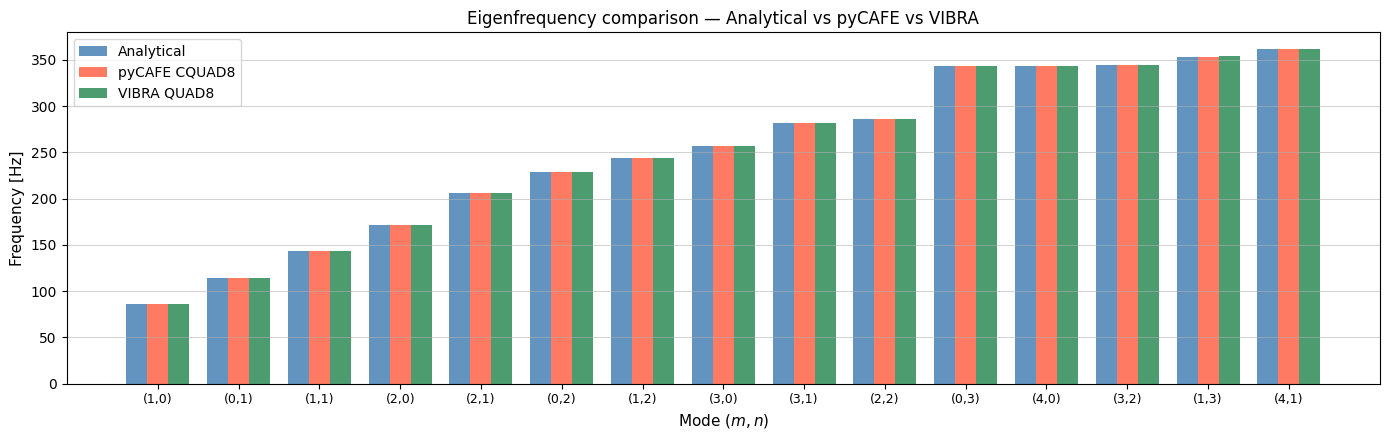

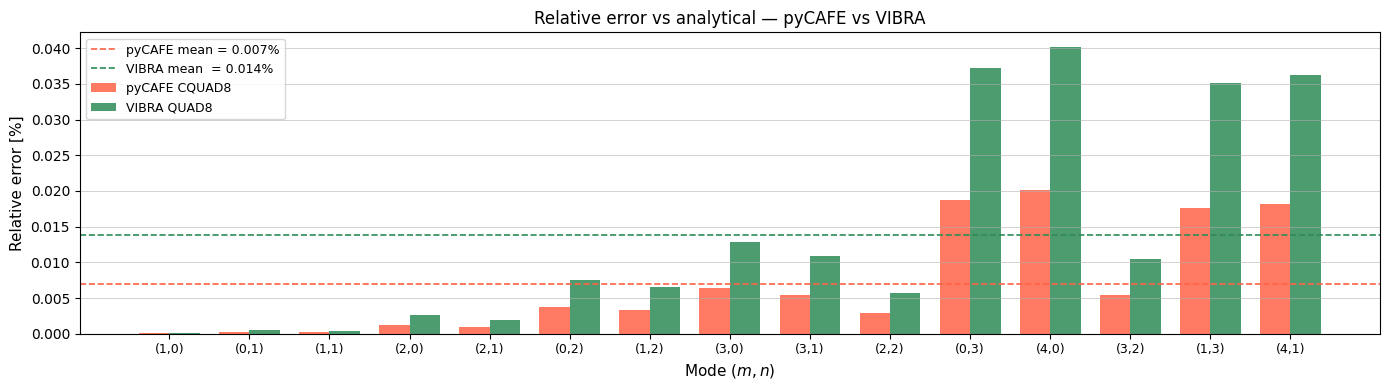

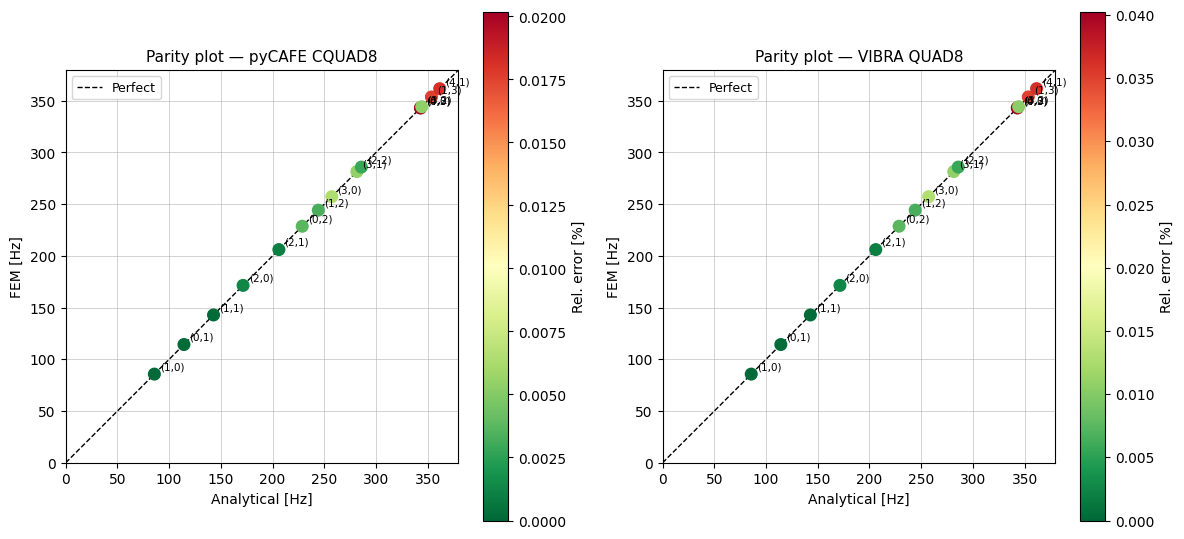

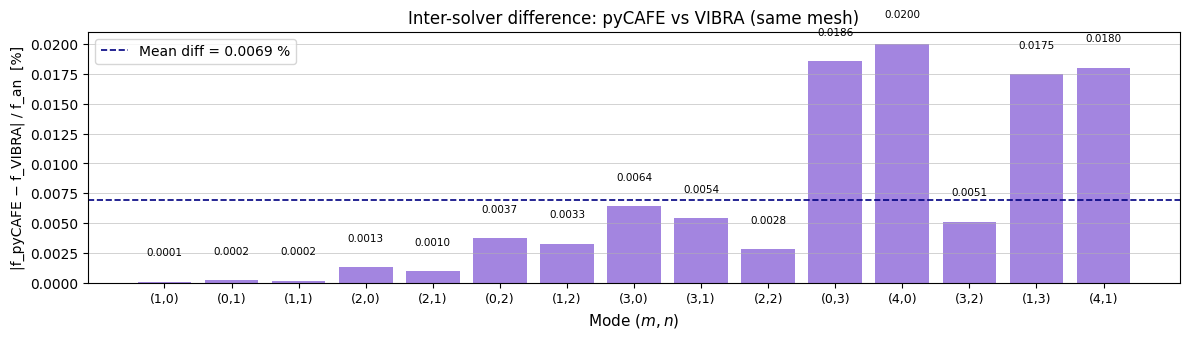

In [16]:
err_p = np.abs(freqs_fem[:n_cmp]    - analytic_freqs[:n_cmp]) / analytic_freqs[:n_cmp] * 100
err_v = np.abs(freqs_vibra[:n_cmp]  - analytic_freqs[:n_cmp]) / analytic_freqs[:n_cmp] * 100
x     = np.arange(n_cmp)
lbls  = analytic_labels[:n_cmp]

# ── Figure 1: frequency comparison — 3 bars ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4.5))
w = 0.26
ax.bar(x - w,   analytic_freqs[:n_cmp], width=w, label="Analytical",
       color="steelblue", alpha=0.85)
ax.bar(x,        freqs_fem[:n_cmp],      width=w, label="pyCAFE CQUAD8",
       color="tomato",    alpha=0.85)
ax.bar(x + w,   freqs_vibra[:n_cmp],    width=w, label="VIBRA QUAD8",
       color="seagreen",  alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(lbls, fontsize=9)
ax.set_xlabel("Mode $(m,n)$", fontsize=11)
ax.set_ylabel("Frequency [Hz]", fontsize=11)
ax.set_title("Eigenfrequency comparison — Analytical vs pyCAFE vs VIBRA", fontsize=12)
ax.legend(fontsize=10); ax.grid(axis="y", linewidth=0.4)
plt.tight_layout(); plt.show()

# ── Figure 2: relative error comparison ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
w = 0.38
ax.bar(x - w/2, err_p, width=w, label="pyCAFE CQUAD8",
       color="tomato",   alpha=0.85)
ax.bar(x + w/2, err_v, width=w, label="VIBRA QUAD8",
       color="seagreen", alpha=0.85)
ax.axhline(err_p.mean(), color="tomato",   linestyle="--", linewidth=1.2,
           label=f"pyCAFE mean = {err_p.mean():.3f}%")
ax.axhline(err_v.mean(), color="seagreen", linestyle="--", linewidth=1.2,
           label=f"VIBRA mean  = {err_v.mean():.3f}%")
ax.set_xticks(x); ax.set_xticklabels(lbls, fontsize=9)
ax.set_xlabel("Mode $(m,n)$", fontsize=11)
ax.set_ylabel("Relative error [%]", fontsize=11)
ax.set_title("Relative error vs analytical — pyCAFE vs VIBRA", fontsize=12)
ax.legend(fontsize=9); ax.grid(axis="y", linewidth=0.4)
plt.tight_layout(); plt.show()

# ── Figure 3: parity plot for both solvers ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
lim = analytic_freqs[:n_cmp].max() * 1.05
for ax, (ff, lbl, col) in zip(axes, [
        (freqs_fem[:n_cmp],   "pyCAFE CQUAD8", "tomato"),
        (freqs_vibra[:n_cmp], "VIBRA QUAD8",   "seagreen")]):
    sc = ax.scatter(analytic_freqs[:n_cmp], ff,
                    c=np.abs(ff-analytic_freqs[:n_cmp])/analytic_freqs[:n_cmp]*100,
                    cmap="RdYlGn_r", s=70, zorder=3, vmin=0)
    ax.plot([0, lim], [0, lim], "k--", lw=1.0, label="Perfect")
    for i in range(n_cmp):
        ax.annotate(lbls[i], (analytic_freqs[i], ff[i]),
                    xytext=(4,3), textcoords="offset points", fontsize=7.5)
    plt.colorbar(sc, ax=ax, label="Rel. error [%]")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
    ax.set_xlabel("Analytical [Hz]", fontsize=10)
    ax.set_ylabel("FEM [Hz]", fontsize=10)
    ax.set_title(f"Parity plot — {lbl}", fontsize=11)
    ax.legend(fontsize=9); ax.grid(linewidth=0.4)
plt.tight_layout(); plt.show()

# ── Figure 4: inter-solver difference ────────────────────────────────────
diff_pv = np.abs(freqs_fem[:n_cmp] - freqs_vibra[:n_cmp]) / analytic_freqs[:n_cmp] * 100
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(x, diff_pv, color="mediumpurple", alpha=0.85)
ax.axhline(diff_pv.mean(), color="navy", linestyle="--", linewidth=1.2,
           label=f"Mean diff = {diff_pv.mean():.4f} %")
for bar, v in zip(ax.patches, diff_pv):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{v:.4f}", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(lbls, fontsize=9)
ax.set_xlabel("Mode $(m,n)$", fontsize=11)
ax.set_ylabel("|f_pyCAFE − f_VIBRA| / f_an  [%]", fontsize=10)
ax.set_title("Inter-solver difference: pyCAFE vs VIBRA (same mesh)", fontsize=12)
ax.legend(fontsize=10); ax.grid(axis="y", linewidth=0.4)
plt.tight_layout(); plt.show()


---
## 11 — Summary

The results confirm that:

1. **pyCAFE correctly recovers the analytical eigenfrequencies** of the rigid rectangular cavity with relative errors well below 1 % for a mesh satisfying the $\lambda_{\min}/5$ criterion with CQUAD8 elements.

2. **Mode shapes match the analytical cosine products**, with consistent spatial patterns for all computed modes.

3. **The convergence rate** with mesh refinement is consistent with the $\mathcal{O}(h^4)$ theoretical estimate for second-order elements, confirming the correctness of the element formulation.

This benchmark is routinely used to validate acoustic FEM codes and was recommended by reviewers as a quality-control exercise (Reviewers R3, R4, R5).

---
## References

1. **Kinsler, L.E., Frey, A.R., Coppens, A.B., Sanders, J.V.** (2000). *Fundamentals of Acoustics*, 4th ed. John Wiley & Sons. — Chapter 9: standing waves in enclosures; derivation of $f_{mn}$ for rigid rectangular cavities.

2. **Morse, P.M., Ingard, K.U.** (1986). *Theoretical Acoustics*. Princeton University Press. — Section 9.2: normal modes of rectangular rooms; analytical eigenfunction solutions.

3. **Ihlenburg, F.** (1998). *Finite Element Analysis of Acoustic Scattering*. Springer. — Chapter 3: error analysis and convergence theory for FEM applied to the Helmholtz equation; $\mathcal{O}(h^{2p})$ eigenfrequency error for $p$-th order elements.

4. **Zienkiewicz, O.C., Taylor, R.L., Zhu, J.Z.** (2005). *The Finite Element Method: Its Basis and Fundamentals*, 6th ed. Butterworth-Heinemann. — Chapter 19: acoustic fluid FEM; stiffness and mass matrix assembly; convergence criteria.

5. **Geuzaine, C., Remacle, J.-F.** (2009). Gmsh: a three-dimensional finite element mesh generator with built-in pre- and post-processing facilities. *International Journal for Numerical Methods in Engineering*, 79(11), 1309–1331. — mesh generation tool used in this notebook.

6. **Pierce, A.D.** (1989). *Acoustics: An Introduction to Its Physical Principles and Applications*. Acoustical Society of America. — Chapter 6: resonance and standing waves in acoustic enclosures; modal density estimates.